In [1]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
import pandas as pd

from LoadTSV import *

In [2]:
WIDTH = 6.0 
HEIGHT = 2.5

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [7]:
# Solver and simulation parameters
M_vector = [4, 5]
closure = "ExtGram"
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 1.0
v_L = 0.5
theta_L = 1.0
rho_R = 1.0
v_R = -0.5
theta_R = 1.0

x_lower = -10.0
x_upper = 10.0

In [8]:
colors = ['blue', 'orange', 'green', 'red', 'purple']
linestyles = ['--', '-', ':']

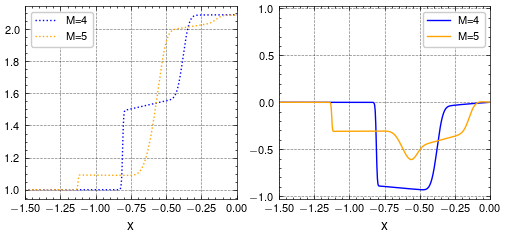

In [11]:
fig, axs = plt.subplots(1, 2)
    
[ax.set_xlim(-1.5, 0)  for ax in axs]
[ax.set_xlabel('x') for ax in axs]
p_vector, q_vector = [], []
for m, M in enumerate(M_vector):
    file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

    x, u, _ = sol_final(file)
    rho = u[:, 0]
    v = u[:, 1] / rho
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    theta = p / rho

    axs[0].plot(x, p, color=colors[m], ls=linestyles[2], label=f'M={M}')
    p_vector.append(p)

    file_prim = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv"

    x, w, _ = sol_final(file_prim)
    Q = w[:, 3]
    q_vector.append(Q)

    axs[1].plot(x, Q, color=colors[m], label=f'M={M}')

[ax.legend() for ax in axs]